In [1]:
import pandas as pd
import os

In [7]:
import pandas as pd
import os

# 1. Define the folder and the 9 files [cite: 101]
folder_path = 'eda'
file_names = [
    'loans_master.csv', 'customer_bureau.csv', 'payment_history.csv',
    'loan_performance.csv', 'monthly_emi_track.csv', 'collateral_assets.csv',
    'branch_region_economy.csv', 'credit_card_behavior.csv', 'loan_enquiry_bureau.csv'
]

# Dictionaries to store our loaded dataframes and memory tracking
dataframes = {}
total_mem_before = 0
total_mem_after = 0
chunk_size = 500_000  # As required to avoid memory overflow [cite: 123]

print("--- Starting Data Loading and Downcasting ---")

# 2. Loop through each file, load in chunks, and downcast
for file in file_names:
    # Combine the folder name with the file name (e.g., 'eda/loans_master.csv')
    file_path = os.path.join(folder_path, file)
    print(f"Processing {file_path}...")
    
    chunks = []
    # Read in chunks to avoid memory overflow [cite: 18, 123]
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        
        # Calculate memory before downcasting
        mem_before = chunk.memory_usage(deep=True).sum()
        total_mem_before += mem_before
        
        # Downcast float64 to float32 and int64 to int32 [cite: 132]
        for col in chunk.columns:
            if chunk[col].dtype == 'float64':
                chunk[col] = chunk[col].astype('float32')
            elif chunk[col].dtype == 'int64':
                chunk[col] = chunk[col].astype('int32')
                
        # Calculate memory after downcasting
        mem_after = chunk.memory_usage(deep=True).sum()
        total_mem_after += mem_after
        
        chunks.append(chunk)
    
    # Concatenate all chunks for this specific table [cite: 18]
    dataframes[file] = pd.concat(chunks, ignore_index=True)

# Print Memory Usage Results
print("\n--- (i) Memory Usage Report ---")
print(f"Total Memory Before Downcasting: {total_mem_before / (1024**2):.2f} MB")
print(f"Total Memory After Downcasting: {total_mem_after / (1024**2):.2f} MB")

# 3. Save to Parquet [cite: 18, 124]
# Saving the first file as an example to get the file size for your Q1(a) answer
test_parquet_name = 'loans_master_downcasted.parquet'
dataframes['loans_master.csv'].to_parquet(test_parquet_name)

# Print File Size Result
file_size_mb = os.path.getsize(test_parquet_name) / (1024**2)
print("\n--- (ii) File Size Report ---")
print(f"File size of the resulting Parquet ({test_parquet_name}): {file_size_mb:.2f} MB")

--- Starting Data Loading and Downcasting ---
Processing eda/loans_master.csv...
Processing eda/customer_bureau.csv...
Processing eda/payment_history.csv...
Processing eda/loan_performance.csv...
Processing eda/monthly_emi_track.csv...
Processing eda/collateral_assets.csv...
Processing eda/branch_region_economy.csv...
Processing eda/credit_card_behavior.csv...
Processing eda/loan_enquiry_bureau.csv...

--- (i) Memory Usage Report ---
Total Memory Before Downcasting: 8246.21 MB
Total Memory After Downcasting: 7200.98 MB

--- (ii) File Size Report ---
File size of the resulting Parquet (loans_master_downcasted.parquet): 60.90 MB


In [18]:
# 1. Initialize the base dataframe with our primary table (loans_master)
master_df = dataframes['loans_master.csv']
expected_rows = 2_000_000

# Define the order of the remaining 8 tables to merge
tables_to_merge = [
    'customer_bureau.csv', 'payment_history.csv', 'loan_performance.csv', 
    'monthly_emi_track.csv', 'collateral_assets.csv', 'branch_region_economy.csv', 
    'credit_card_behavior.csv', 'loan_enquiry_bureau.csv'
]

total_orphan_records = 0

print("--- Starting Sequential Left Merges ---")

# 2. Loop through and merge sequentially
for table_name in tables_to_merge:
    right_df = dataframes[table_name]
    
    # Calculate Orphan Records: 
    # Find 'loan_id's that exist in the right table but NOT in the master table
    orphans = len(set(right_df['loan_id']) - set(master_df['loan_id']))
    total_orphan_records += orphans
    # Perform the Left Merge
    master_df = master_df.merge(right_df, on='loan_id', how='left')
    
    # Assert that the row count is exactly 2,000,000
    try:
        assert master_df.shape[0] == expected_rows
        print(f"Merged {table_name} successfully. Row count validated: {master_df.shape[0]}. Orphans found: {orphans}")
    except AssertionError:
        print(f"ERROR: Row count violated after merging {table_name}! Count is now: {master_df.shape[0]}")

print("\n--- Final Merge Summary ---")
print(f"Final merged dataset shape: {master_df.shape}")
print(f"Total orphan records detected: {total_orphan_records}")

--- Starting Sequential Left Merges ---
total0
Merged customer_bureau.csv successfully. Row count validated: 2000000. Orphans found: 0
total0
Merged payment_history.csv successfully. Row count validated: 2000000. Orphans found: 0
total0
Merged loan_performance.csv successfully. Row count validated: 2000000. Orphans found: 0
total0
Merged monthly_emi_track.csv successfully. Row count validated: 2000000. Orphans found: 0
total0
Merged collateral_assets.csv successfully. Row count validated: 2000000. Orphans found: 0
total0
Merged branch_region_economy.csv successfully. Row count validated: 2000000. Orphans found: 0
total0
Merged credit_card_behavior.csv successfully. Row count validated: 2000000. Orphans found: 0
total0
Merged loan_enquiry_bureau.csv successfully. Row count validated: 2000000. Orphans found: 0

--- Final Merge Summary ---
Final merged dataset shape: (2000000, 182)
Total orphan records detected: 0


In [11]:
print(master_df)

             loan_id issue_date  issue_year  issue_month  loan_amnt_inr  \
0        LN000000001   Feb-2016        2016            2        80678.0   
1        LN000000002   May-2024        2024            5       274166.0   
2        LN000000003   Dec-2021        2021           12        59603.0   
3        LN000000004   Nov-2020        2020           11       246313.0   
4        LN000000005   Jul-2013        2013            7       101471.0   
...              ...        ...         ...          ...            ...   
1999995  LN001999996   Oct-2018        2018           10        85677.0   
1999996  LN001999997   Apr-2023        2023            4        72216.0   
1999997  LN001999998   Oct-2021        2021           10        52596.0   
1999998  LN001999999   Feb-2016        2016            2        97617.0   
1999999  LN002000000   Jul-2021        2021            7       313106.0   

         funded_amnt_inr  loan_term_months  int_rate_pct  installment_inr  \
0                74992

In [12]:
# 1 (c)
import numpy as np
from sklearn.impute import SimpleImputer, KNNImputer

In [20]:
#Issue 1: Create the binary column
master_df['dirty_flag'] = 0

In [21]:
# Identify negative interest rates and flag them
master_df.loc[master_df['int_rate_pct'] < 0, 'dirty_flag'] = 1

In [22]:
# Calculate the median interest rate for every single row based on its grade
grade_medians = master_df.groupby('grade')['int_rate_pct'].transform('median')

# Find the rows where the interest rate is negative, and replace them with those medians
master_df.loc[master_df['int_rate_pct'] < 0, 'int_rate_pct'] = grade_medians

In [23]:
# Issue 2:1. Calculate the median income based on the borrower's job title
title_medians = master_df.groupby('emp_title')['annual_inc_inr'].transform('median')

In [24]:
# 2. Flag the rows where income is exactly 0
master_df.loc[master_df['annual_inc_inr'] == 0, 'dirty_flag'] = 1

In [25]:
# 3. Replace the 0s with the normal job title median we calculated above
master_df.loc[master_df['annual_inc_inr'] == 0, 'annual_inc_inr'] = title_medians

In [27]:
#Issue 3: Impossible DTI (Debt-to-Income Ratio)
# 1. Calculate the median DTI based on the loan grade
grade_dti_medians = master_df.groupby('grade')['dti_pct'].transform('median')

In [28]:
# 2. Flag the rows where DTI is exactly 999
master_df.loc[master_df['dti_pct'] == 999, 'dirty_flag'] = 1

In [29]:
# 3. Replace the 999s with the normal grade median we calculated above
master_df.loc[master_df['dti_pct'] == 999, 'dti_pct'] = grade_dti_medians

In [37]:
#Issue 4: Negative Revolving Utilization
count = (master_df['revol_util_pct'] < 0).sum()
print(f"Rows with revol_util_pct < 0: {count}")

Rows with revol_util_pct < 0: 0


In [38]:
# 1. Flag the rows where revolving utilization is less than 0
master_df.loc[master_df['revol_util_pct'] < 0, 'dirty_flag'] = 1

In [40]:
# 2. Fix the error by taking the absolute value (turning negatives into positives)
master_df['revol_util_pct'] = master_df['revol_util_pct'].abs()

In [44]:
#Issue 5: Missing Values in Months Since Last Delinquency
# 1. We don't need to use the dirty_flag for missing values, just fix them directly.
# Replace all the blank (NaN) spaces with the number 999
master_df['mths_since_last_delinq'] = master_df['mths_since_last_delinq'].fillna(999)

In [42]:
#Issue 6: High Missing Values in Mortgage Accounts
# 1. Find the most common number (the mode) in the mort_acc column
# [0] grabs the first most common number, which is usually 0
most_common_mort = master_df['mort_acc'].mode()[0]

In [45]:
# 2. Fill all the blank (NaN) spaces with that number
master_df['mort_acc'] = master_df['mort_acc'].fillna(most_common_mort)

In [46]:
#Issue 7: Missing Values in Employment Length
# 1. Figure out the normal (median) employment length for every specific job title
title_emp_medians = master_df.groupby('emp_title')['emp_length_years'].transform('median')

In [48]:
# 2. Fill the blank (NaN) spaces with those specific medians
master_df['emp_length_years'] = master_df['emp_length_years'].fillna(title_emp_medians)

In [49]:
# 3. Safety check: If a rare job title was completely blank for everyone, fill remaining blanks with the overall median
overall_median = master_df['emp_length_years'].median()
master_df['emp_length_years'] = master_df['emp_length_years'].fillna(overall_median)

In [52]:
#Issue 8: Moderate Missing Values in Installment Loan Utilization

from sklearn.impute import KNNImputer

print("Starting optimized KNN Imputation...")

# 1. Set up the KNN Imputer
knn = KNNImputer(n_neighbors=5)

# 2. Grab a small random sample of 1,000 valid rows to "train" the imputer fast
valid_data = master_df[['il_util_pct']].dropna().sample(n=1000, random_state=42)
knn.fit(valid_data)

# 3. Find exactly where the missing values are
missing_mask = master_df['il_util_pct'].isnull()

# 4. Use the trained KNN to quickly predict ONLY the missing rows
missing_data = master_df.loc[missing_mask, ['il_util_pct']]
master_df.loc[missing_mask, 'il_util_pct'] = knn.transform(missing_data)

print("Issue 8 complete! Missing values filled successfully.")

Starting optimized KNN Imputation...
Issue 8 complete! Missing values filled successfully.


In [53]:
# E : 


In [59]:
import pandas as pd

# 1. Update this list if you found the new spelling in Step 1!
skewed_cols = [
    'revol_bal_inr', 'mort_acc', 'avg_cur_bal_inr', 'total_cc_balance_inr'
]

summary_data = []

print("Starting Winsorization...")

# 2. Only run the loop for columns that ACTUALLY exist in your dataframe
for col in skewed_cols:
    if col not in master_df.columns:
        print(f"⚠️ SKIPPED: Column '{col}' not found in dataframe. Check spelling!")
        continue # Skip to the next column
        
    # Record BEFORE statistics
    mean_before = master_df[col].mean()
    std_before = master_df[col].std()
    max_before = master_df[col].max()
    
    # Find the 1st and 99th percentile limits
    p01 = master_df[col].quantile(0.01)
    p99 = master_df[col].quantile(0.99)
    
    # WINSORIZE: Cap the extreme highs and lows
    master_df[col] = master_df[col].clip(lower=p01, upper=p99)
    
    # Record AFTER statistics
    mean_after = master_df[col].mean()
    std_after = master_df[col].std()
    max_after = master_df[col].max()
    
    # Save the results for the table
    summary_data.append({
        'Feature': col,
        'Mean (Before)': round(mean_before, 2),
        'Mean (After)': round(mean_after, 2),
        'Std Dev (Before)': round(std_before, 2),
        'Std Dev (After)': round(std_after, 2),
        'Max (Before)': round(max_before, 2),
        'Max (After)': round(max_after, 2)
    })

# 3. Display the final Summary Table
summary_df = pd.DataFrame(summary_data)
display(summary_df)

Starting Winsorization...


,Feature,Mean (Before),Mean (After),Std Dev (Before),Std Dev (After),Max (Before),Max (After)
0,revol_bal_inr,27437.679688,26072.190000,48713.42,35993.60,3000000.00,218004.78
1,mort_acc,1.050000,1.050000,1.28,1.28,5.00,5.00
2,avg_cur_bal_inr,3738.270020,3284.090088,12547.08,6600.88,2434032.75,44733.44
3,total_cc_balance_inr,44042.679688,42899.320000,73096.96,66011.46,986450.00,366026.05


In [60]:
# QUESTION 2   EXPLORATORY DATA ANALYSIS

Exact Default Rate: 3.88%
Performing Rate: 96.12%


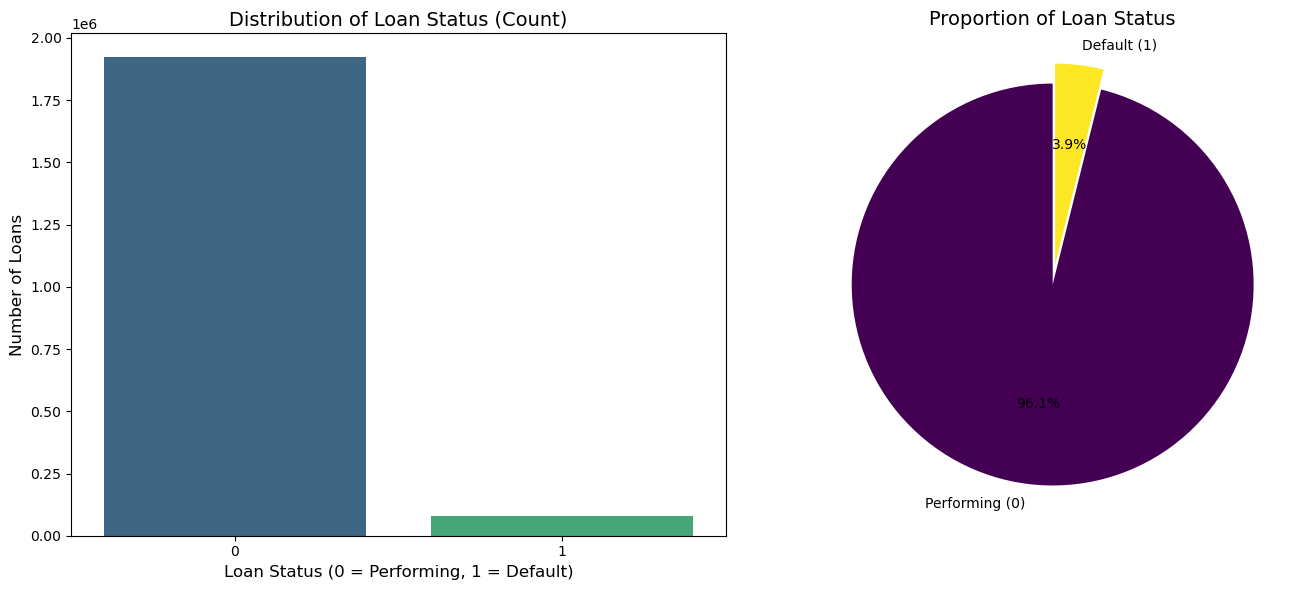

In [65]:
# a
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the exact percentages
status_counts = master_df['loan_status'].value_counts()
status_pct = master_df['loan_status'].value_counts(normalize=True) * 100

exact_default_rate = status_pct[1]
print(f"Exact Default Rate: {exact_default_rate:.2f}%")
print(f"Performing Rate: {status_pct[0]:.2f}%")

# 2. Set up the figure for two side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Chart 1: Bar Chart ---
sns.countplot(data=master_df, x='loan_status', ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Loan Status (Count)', fontsize=14)
axes[0].set_xlabel('Loan Status (0 = Performing, 1 = Default)', fontsize=12)
axes[0].set_ylabel('Number of Loans', fontsize=12)

# --- Chart 2: Pie Chart ---
axes[1].pie(status_counts, labels=['Performing (0)', 'Default (1)'], autopct='%1.1f%%', 
            colors=['#440154', '#fde725'], startangle=90, explode=(0, 0.1))
axes[1].set_title('Proportion of Loan Status', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
# b

In [67]:
# 1. Separate the CIBIL scores by loan status
perf_cibil = master_df[master_df['loan_status'] == 0]['cibil_score'].dropna()
def_cibil = master_df[master_df['loan_status'] == 1]['cibil_score'].dropna()

In [68]:
# 2. Calculate Means
mean_perf = perf_cibil.mean()
mean_def = def_cibil.mean()

In [70]:
# 4. Calculate Empirical Distributional Overlap
bins = np.linspace(300, 900, 100)
hist_perf, _ = np.histogram(perf_cibil, bins=bins, density=True)
hist_def, _ = np.histogram(def_cibil, bins=bins, density=True)
overlap_pct = np.sum(np.minimum(hist_perf, hist_def)) * (bins[1] - bins[0]) * 100

In [71]:
# Print the required metrics
print(f"Mean CIBIL (Performing): {mean_perf:.2f}")
print(f"Mean CIBIL (Defaulted): {mean_def:.2f}")
print(f"Cohen's d: {cohens_d:.2f}")
print(f"Distributional Overlap: {overlap_pct:.2f}%")

Mean CIBIL (Performing): 680.68
Mean CIBIL (Defaulted): 660.11
Cohen's d: 0.24
Distributional Overlap: 90.35%


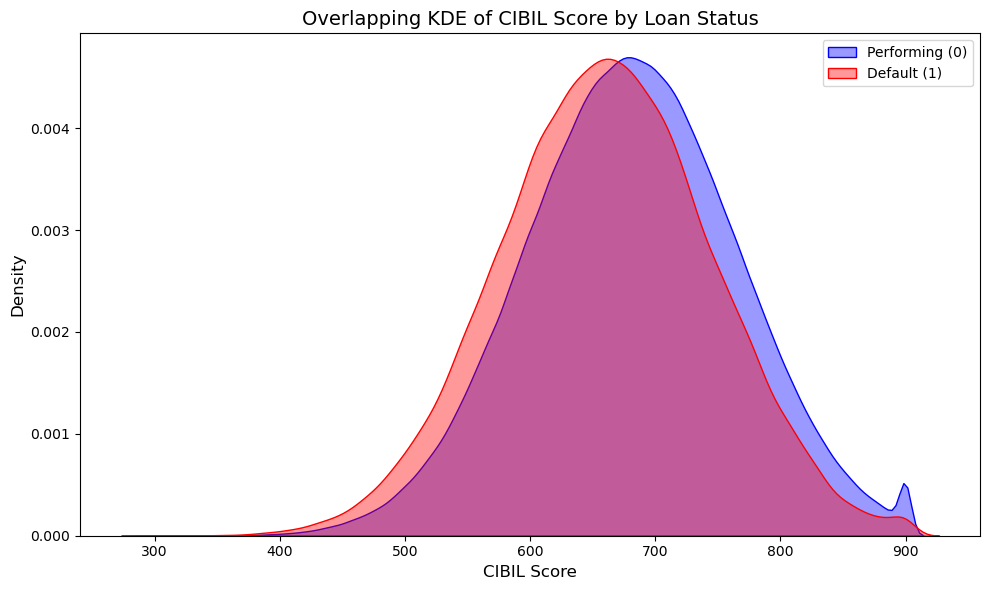

In [72]:
# 5. Plot the overlapping KDE curves
plt.figure(figsize=(10, 6))
sns.kdeplot(perf_cibil, label='Performing (0)', fill=True, color='blue', alpha=0.4)
sns.kdeplot(def_cibil, label='Default (1)', fill=True, color='red', alpha=0.4)

plt.title('Overlapping KDE of CIBIL Score by Loan Status', fontsize=14)
plt.xlabel('CIBIL Score', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# c

In [77]:
# 1. Define the 12 key numeric features using your EXACT column names
numeric_features = [
    'loan_amnt_inr', 'int_rate_pct', 'annual_inc_inr', 'dti_pct', 
    'cibil_score', 'emp_length_years', 'revol_util_pct', 'revol_bal_inr', 
    'total_acc', 'mort_acc', 'avg_cur_bal_inr', 'total_cc_balance_inr'
]

In [78]:
# 2. Check initial skewness
print("--- Initial Skewness ---")
initial_skew = master_df[numeric_features].skew()
print(initial_skew)


--- Initial Skewness ---
loan_amnt_inr           3.651117
int_rate_pct            0.590027
annual_inc_inr          4.675825
dti_pct                 0.597136
cibil_score            -0.034678
emp_length_years        1.939471
revol_util_pct          0.287196
revol_bal_inr           3.063568
total_acc               0.000877
mort_acc                1.131318
avg_cur_bal_inr         4.212462
total_cc_balance_inr    2.682323
dtype: float64


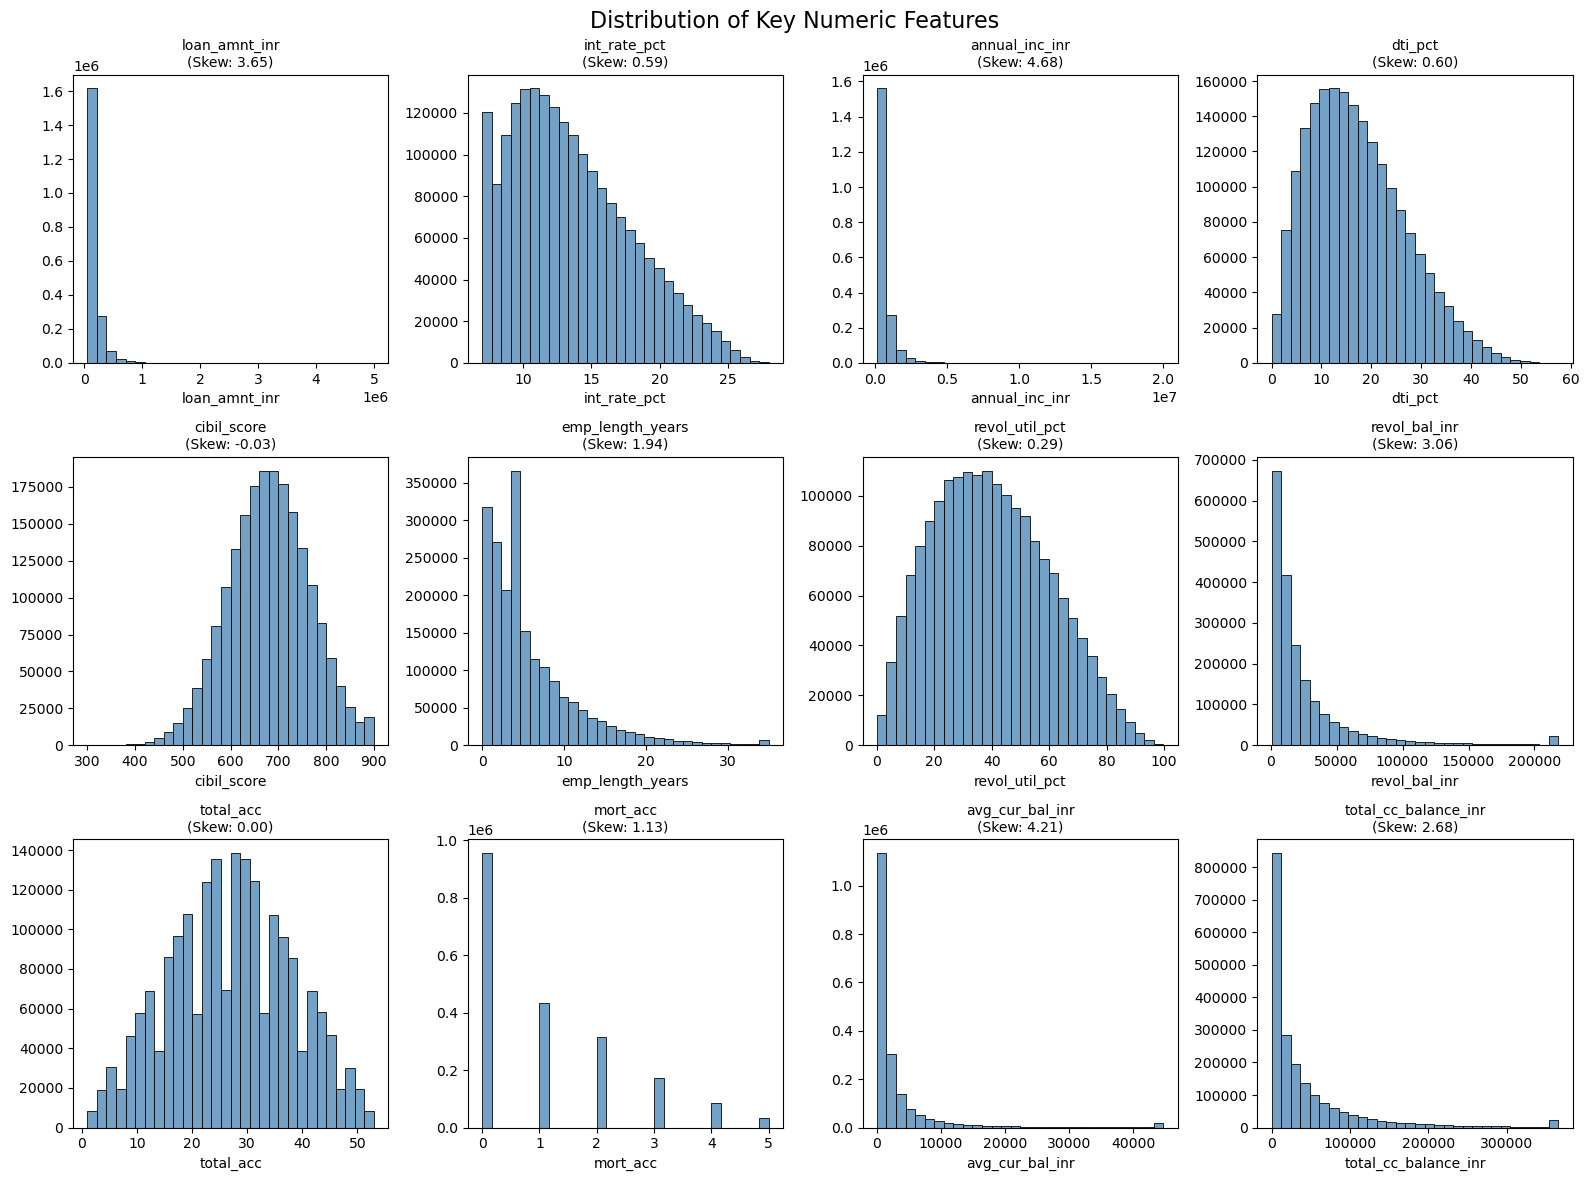

In [79]:
# 3. Plot the 12-panel histogram grid
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Distribution of Key Numeric Features', fontsize=16)

for i, col in enumerate(numeric_features):
    row, col_idx = divmod(i, 4)
    sns.histplot(master_df[col].dropna(), bins=30, ax=axes[row, col_idx], color='steelblue')
    axes[row, col_idx].set_title(f'{col}\n(Skew: {initial_skew[col]:.2f})', fontsize=10)
    axes[row, col_idx].set_ylabel('')

plt.tight_layout()
plt.show()

In [80]:
# 4. Apply Log Transformation (log(1+x)) to the two most skewed features
master_df['log_annual_inc'] = np.log1p(master_df['annual_inc_inr'])
master_df['log_loan_amnt'] = np.log1p(master_df['loan_amnt_inr'])

In [81]:
# 5. Confirm skew reduction
print("\n--- Skewness AFTER Log Transformation ---")
print(f"log_annual_inc skew: {master_df['log_annual_inc'].skew():.2f}")
print(f"log_loan_amnt skew: {master_df['log_loan_amnt'].skew():.2f}")


--- Skewness AFTER Log Transformation ---
log_annual_inc skew: 0.33
log_loan_amnt skew: 0.58


In [82]:
# d

In [83]:
# 1. Grab the top 20 numeric features (excluding ID/dirty flags)
numeric_df = master_df.select_dtypes(include=[np.number])
cols_to_drop = [col for col in numeric_df.columns if 'id' in col.lower() or 'flag' in col.lower() or 'loan_status' in col]
numeric_df = numeric_df.drop(columns=cols_to_drop, errors='ignore')

In [84]:
# Get the first 20 valid numeric columns
top_20_cols = numeric_df.columns[:20]

In [85]:
# 2. Compute Pearson correlation matrix
corr_matrix = master_df[top_20_cols].corr()

In [86]:
# 3. Find specific pairs where correlation is > 0.75 or < -0.75
print("--- Highly Correlated Pairs (|r| > 0.75) ---")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.75:
            colname1 = corr_matrix.columns[i]
            colname2 = corr_matrix.columns[j]
            corr_val = corr_matrix.iloc[i, j]
            print(f"{colname1} and {colname2}: {corr_val:.2f}")

--- Highly Correlated Pairs (|r| > 0.75) ---
funded_amnt_inr and loan_amnt_inr: 1.00
installment_inr and loan_amnt_inr: 0.84
installment_inr and funded_amnt_inr: 0.84
annual_installment_inr and loan_amnt_inr: 0.84
annual_installment_inr and funded_amnt_inr: 0.84
annual_installment_inr and installment_inr: 1.00
rate_spread_pct and int_rate_pct: 0.97
real_interest_rate_pct and int_rate_pct: 0.91
real_interest_rate_pct and rate_spread_pct: 0.91


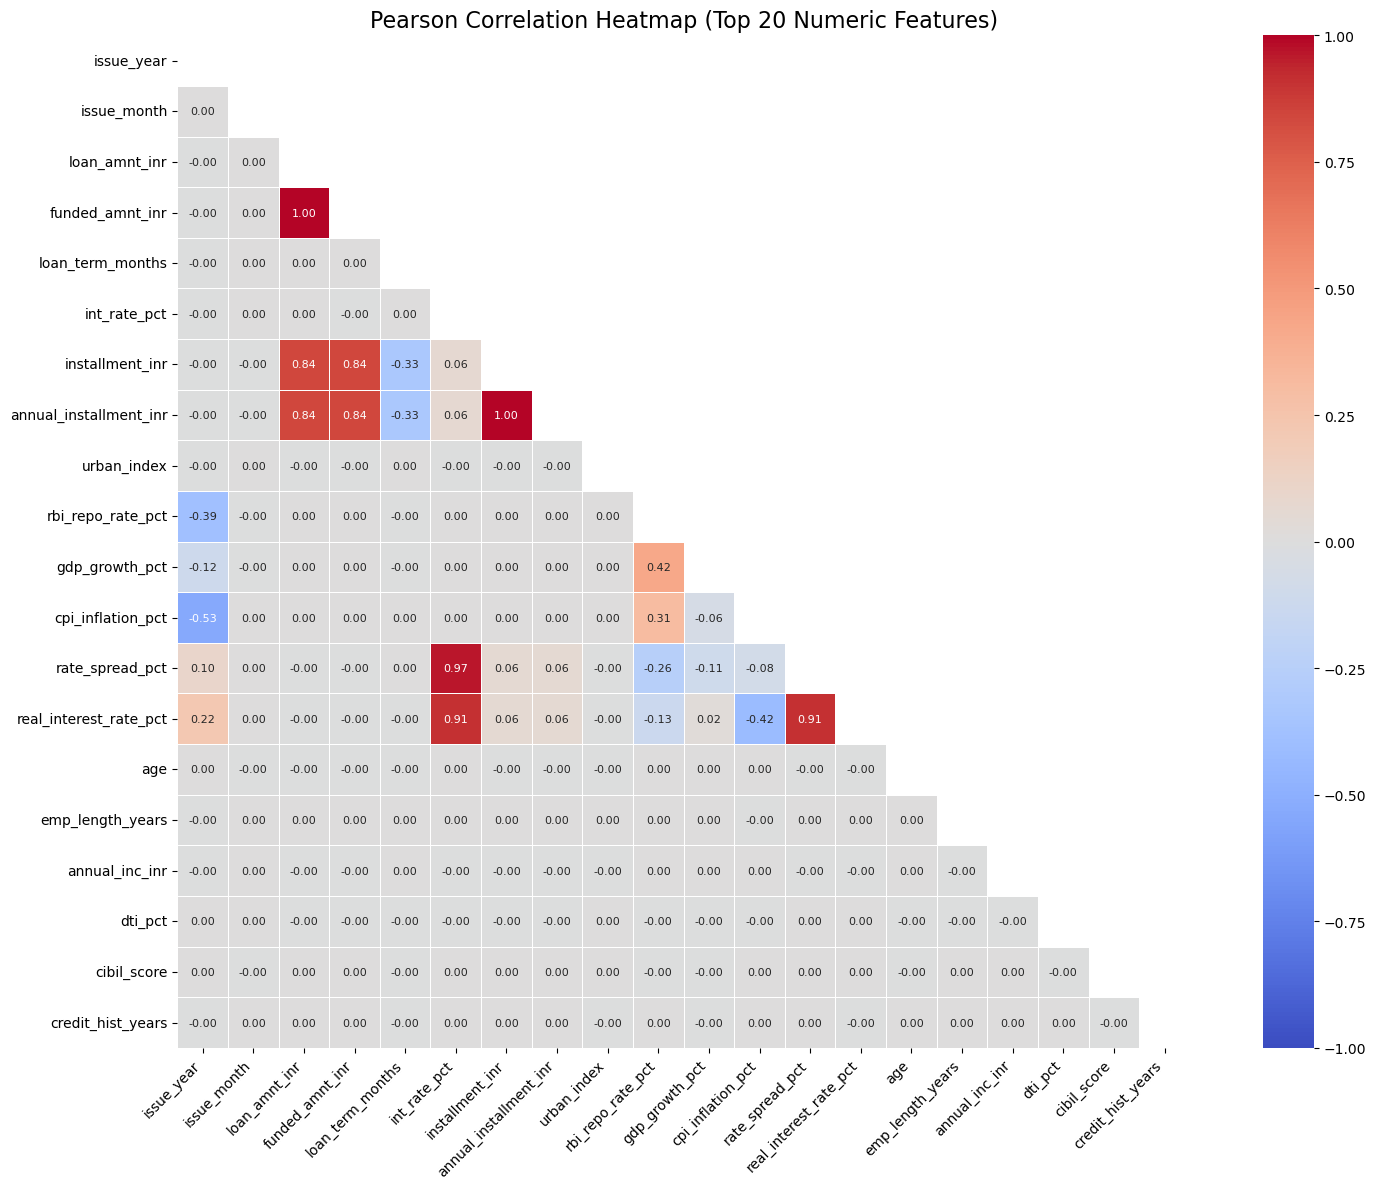

In [87]:
# 4. Plot the Heatmap
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=.5, annot_kws={"size": 8})

plt.title('Pearson Correlation Heatmap (Top 20 Numeric Features)', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# E

In [88]:
# 1. Define the 6 specific features requested
features = [
    'int_rate_pct', 'dti_pct', 'cibil_score', 
    'annual_inc_inr', 'revol_util_pct', 'emp_length_years'
]

# Ensure columns exist to prevent crashes
features = [f for f in features if f in master_df.columns]

In [89]:
# 2. Calculate and print the exact median differences
print("--- Median Differences (Default vs Performing) ---")
for f in features:
    median_perf = master_df[master_df['loan_status'] == 0][f].median()
    median_def = master_df[master_df['loan_status'] == 1][f].median()
    diff = abs(median_perf - median_def)
    print(f"{f}: Difference = {diff:.2f}")

--- Median Differences (Default vs Performing) ---
int_rate_pct: Difference = 2.47
dti_pct: Difference = 4.44
cibil_score: Difference = 21.00
annual_inc_inr: Difference = 3463.00
revol_util_pct: Difference = 0.80
emp_length_years: Difference = 0.00


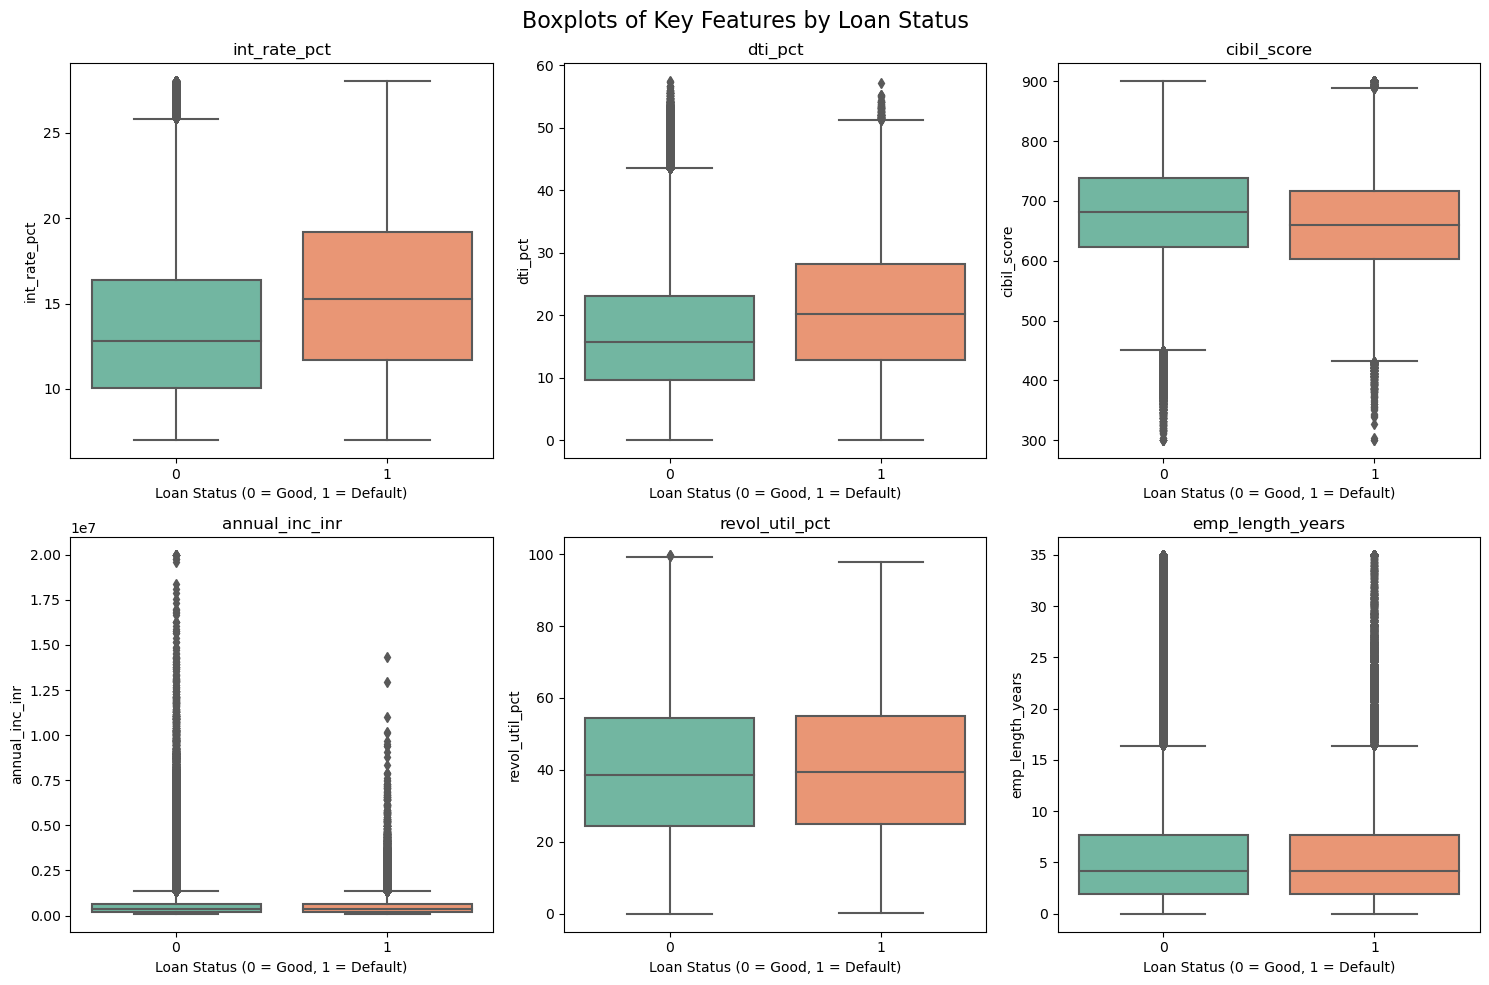

In [90]:
# 3. Plot the 6 side-by-side boxplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Boxplots of Key Features by Loan Status', fontsize=16)

# Flatten axes for easy looping
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(x='loan_status', y=col, data=master_df, ax=axes[i], palette='Set2')
    axes[i].set_title(col)
    axes[i].set_xlabel('Loan Status (0 = Good, 1 = Default)')

plt.tight_layout()
plt.show()

In [91]:
# 1. Calculate the default rate (%) for each loan grade (A to G)
grade_rates = master_df.groupby('grade')['loan_status'].mean() * 100
grade_rates = grade_rates.sort_index()

In [92]:
# 2. Check if it is monotonically ordered (always goes up step-by-step)
is_monotonic = grade_rates.is_monotonic_increasing

In [93]:
# 3. Find the differences (jumps) between each grade
jumps = grade_rates.diff()
max_jump = jumps.max()
grade_after_jump = jumps.idxmax()

# Find the grade right before the big jump
grades_list = grade_rates.index.tolist()
grade_before_jump = grades_list[grades_list.index(grade_after_jump) - 1]

# Print the exact answers you need for your exam paper
print(f"Monotonically Ordered: {'Yes' if is_monotonic else 'No'}")
print(f"Largest Jump: Grade {grade_before_jump} to Grade {grade_after_jump}")
print(f"Jump Size: {max_jump:.2f} percentage points")

Monotonically Ordered: Yes
Largest Jump: Grade F to Grade G
Jump Size: 2.05 percentage points


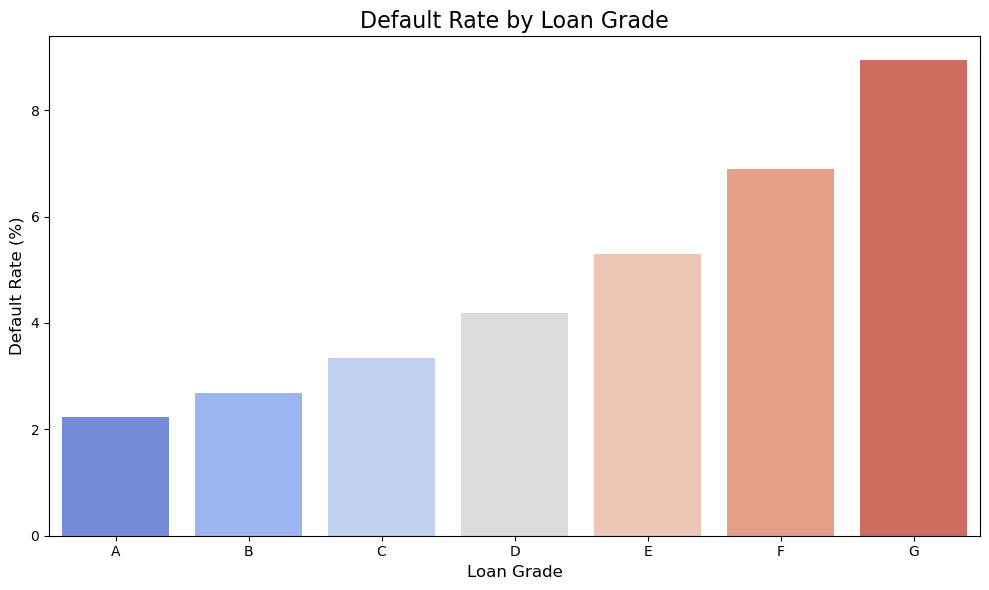

In [94]:
# 4. Plot the Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x=grade_rates.index, y=grade_rates.values, palette='coolwarm')

plt.title('Default Rate by Loan Grade', fontsize=16)
plt.xlabel('Loan Grade', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)

plt.tight_layout()
plt.show()